# Task 4 - Optimize Portfolio Based on Forecast (Modern Portfolio Theory)

Combine the Task 3 TSLA forecast with historical BND/SPY data to build the Efficient
Frontier and recommend an optimal portfolio.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pypfopt import EfficientFrontier, risk_models

sys.path.append(str(Path.cwd().parent))
from src.features import annualized_return

plt.rcParams["figure.figsize"] = (10, 7)
TRADING_DAYS = 252


## 1. Expected returns vector

- **TSLA**: derived from the Task 3 LSTM 12-month recursive forecast (the analyst's
  explicit forward-looking "view" on this asset).
- **BND, SPY**: historical mean daily return, annualized - the standard proxy used when we
  have no special forward view on an asset, only its historical behaviour.

This mirrors a common desk practice: express a specific view on the name you have
researched most closely (TSLA), and fall back to historical averages for the rest.

In [2]:
TICKERS = ["TSLA", "BND", "SPY"]  # canonical order used for every vector/matrix below

combined = pd.read_csv("../data/processed/combined_prices.csv", parse_dates=["Date"])
prices = combined.pivot(index="Date", columns="Asset", values="Adj Close").sort_index()
prices = prices[TICKERS]  # pypfopt aligns mu/cov by *position*, not by label, so a
                          # consistent column order here is required, not cosmetic
full_bdays = pd.date_range(prices.index.min(), prices.index.max(), freq="B")
prices = prices.reindex(full_bdays).ffill()
prices.index.name = "Date"

returns = prices.pct_change().dropna()

hist_ann_return = {
    "BND": annualized_return(returns["BND"]),
    "SPY": annualized_return(returns["SPY"]),
}

forecast = pd.read_csv("../data/processed/tsla_future_forecast.csv", index_col=0, parse_dates=True)
last_price = prices["TSLA"].iloc[-1]
tsla_12m_price = forecast["forecast"].iloc[-1]
tsla_forecast_return = tsla_12m_price / last_price - 1  # annualized, since horizon ~= 1 year

mu = pd.Series({
    "TSLA": tsla_forecast_return,
    "BND": hist_ann_return["BND"],
    "SPY": hist_ann_return["SPY"],
})[TICKERS]
mu


TSLA   -0.325216
BND     0.019231
SPY     0.139070
dtype: float64

## 2. Covariance matrix (historical daily returns, annualized)

Uses PyPortfolioOpt's sample covariance estimator (Ledoit-Wolf-shrinkage-free sample
covariance) on daily returns for all three assets, annualized to match the return
vector's units.

In [3]:
cov_matrix = risk_models.sample_cov(prices, returns_data=False, frequency=TRADING_DAYS)
cov_matrix


Asset,TSLA,BND,SPY
Asset,,,
TSLA,0.315057,0.001739,0.048016
BND,0.001739,0.002721,0.001046
SPY,0.048016,0.001046,0.030037


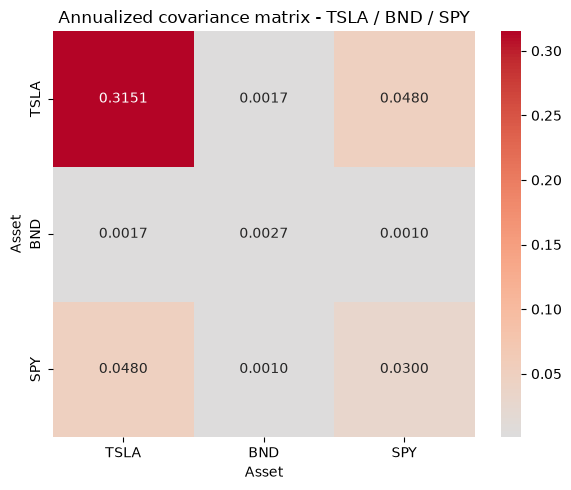

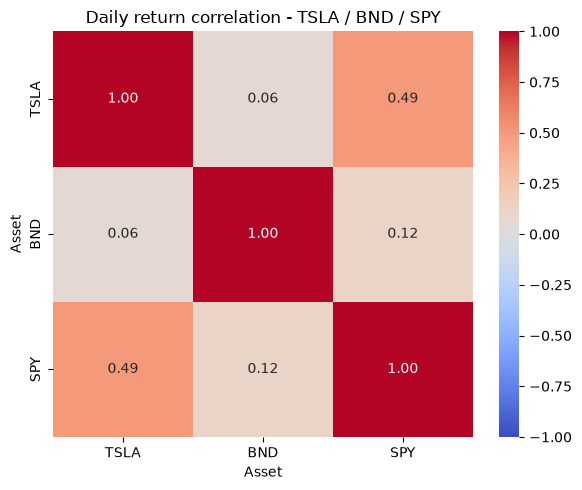

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cov_matrix, annot=True, fmt=".4f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Annualized covariance matrix - TSLA / BND / SPY")
plt.tight_layout()
plt.savefig("../reports/figures/covariance_heatmap.png", dpi=120)
plt.show()

corr = returns[["TSLA", "BND", "SPY"]].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Daily return correlation - TSLA / BND / SPY")
plt.tight_layout()
plt.savefig("../reports/figures/correlation_heatmap.png", dpi=120)
plt.show()


## 3. Efficient Frontier

Sweep target returns across the feasible range and solve the minimum-volatility portfolio
at each one, tracing out the Efficient Frontier. Mark the Maximum Sharpe Ratio (tangency)
portfolio and the Minimum Volatility portfolio.

In [5]:
RISK_FREE_RATE = 0.0

ef_maxsharpe = EfficientFrontier(mu, cov_matrix, weight_bounds=(0, 1))
ef_maxsharpe.max_sharpe(risk_free_rate=RISK_FREE_RATE)
w_max_sharpe = ef_maxsharpe.clean_weights()
ret_ms, vol_ms, sharpe_ms = ef_maxsharpe.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

ef_minvol = EfficientFrontier(mu, cov_matrix, weight_bounds=(0, 1))
ef_minvol.min_volatility()
w_min_vol = ef_minvol.clean_weights()
ret_mv, vol_mv, sharpe_mv = ef_minvol.portfolio_performance(risk_free_rate=RISK_FREE_RATE)

print("Max Sharpe weights:", w_max_sharpe)
print(f"  return={ret_ms:.2%}  vol={vol_ms:.2%}  sharpe={sharpe_ms:.2f}")
print()
print("Min Volatility weights:", w_min_vol)
print(f"  return={ret_mv:.2%}  vol={vol_mv:.2%}  sharpe={sharpe_mv:.2f}")


Max Sharpe weights: OrderedDict({'TSLA': 0.0, 'BND': 0.54674, 'SPY': 0.45326})
  return=7.35%  vol=8.66%  sharpe=0.85

Min Volatility weights: OrderedDict({'TSLA': 0.0, 'BND': 0.9454, 'SPY': 0.0546})
  return=2.58%  vol=5.13%  sharpe=0.50


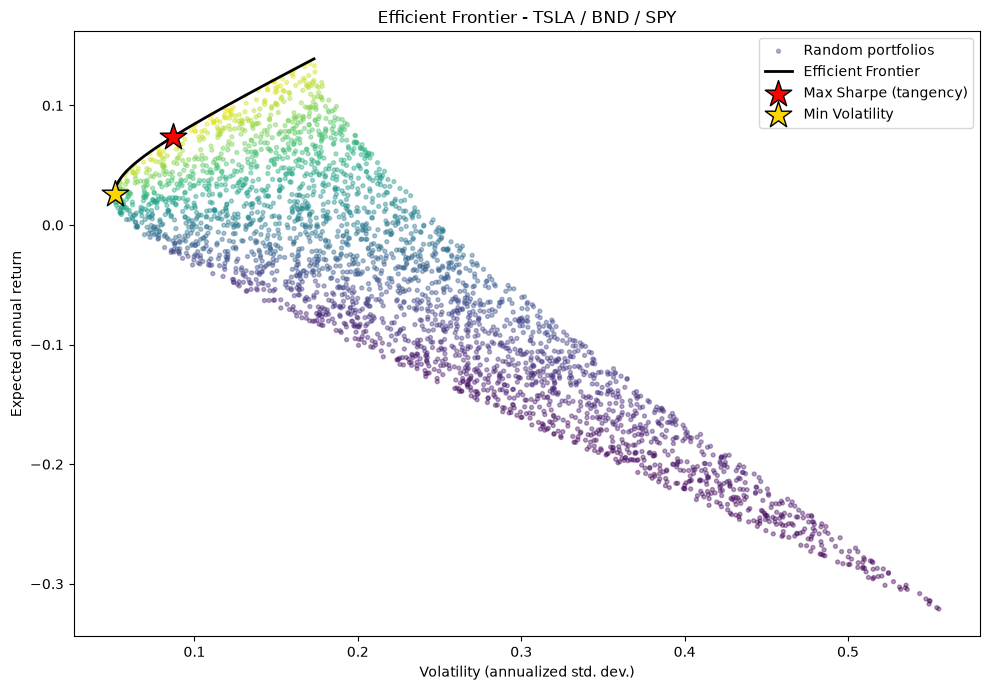

In [6]:
n_points = 200
target_returns = np.linspace(mu.min() + 1e-4, mu.max() - 1e-4, n_points)
frontier_vol = []
frontier_ret = []
for target in target_returns:
    try:
        ef = EfficientFrontier(mu, cov_matrix, weight_bounds=(0, 1))
        ef.efficient_return(target)
        r, v, _ = ef.portfolio_performance(risk_free_rate=RISK_FREE_RATE)
        frontier_ret.append(r)
        frontier_vol.append(v)
    except Exception:
        continue

# Random portfolios as a visual backdrop for context
rng = np.random.default_rng(42)
n_random = 3000
rand_weights = rng.dirichlet(np.ones(3), n_random)
rand_ret = rand_weights @ mu.values
rand_vol = np.sqrt(np.einsum("ij,jk,ik->i", rand_weights, cov_matrix.values, rand_weights))

fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(rand_vol, rand_ret, c=rand_ret / rand_vol, cmap="viridis", s=8, alpha=0.4, label="Random portfolios")
ax.plot(frontier_vol, frontier_ret, color="black", lw=2, label="Efficient Frontier")
ax.scatter([vol_ms], [ret_ms], marker="*", s=400, color="red", edgecolor="black", label="Max Sharpe (tangency)", zorder=5)
ax.scatter([vol_mv], [ret_mv], marker="*", s=400, color="gold", edgecolor="black", label="Min Volatility", zorder=5)
ax.set_xlabel("Volatility (annualized std. dev.)")
ax.set_ylabel("Expected annual return")
ax.set_title("Efficient Frontier - TSLA / BND / SPY")
ax.legend()
plt.tight_layout()
plt.savefig("../reports/figures/efficient_frontier.png", dpi=120)
plt.show()


## 4. Recommended portfolio

We recommend the **Maximum Sharpe Ratio (tangency) portfolio**: it maximizes risk-adjusted
return rather than raw return or raw risk in isolation, which is the standard
institutional criterion when a client's specific risk tolerance is not otherwise
specified, and is consistent with GMF's stated goal of "minimizing risks and capitalizing
on market opportunities" rather than pure return maximization. The Minimum Volatility
portfolio remains the appropriate alternative for a more risk-averse client mandate.

In [7]:
recommendation = pd.DataFrame({
    "Max Sharpe (recommended)": {**w_max_sharpe, "Expected Return": ret_ms, "Volatility": vol_ms, "Sharpe Ratio": sharpe_ms},
    "Min Volatility": {**w_min_vol, "Expected Return": ret_mv, "Volatility": vol_mv, "Sharpe Ratio": sharpe_mv},
}).T
recommendation.to_csv("../data/processed/task4_portfolio_recommendation.csv")
recommendation


,TSLA,BND,SPY,Expected Return,Volatility,Sharpe Ratio
Max Sharpe (recommended),0.0,0.54674,0.45326,0.073548,0.086618,0.849109
Min Volatility,0.0,0.94540,0.05460,0.025774,0.051276,0.502654
